In [ ]:
import pandas as pd

# Load the uploaded dataset
file_path = "/content/Dataset.csv"
df = pd.read_csv(file_path)

# Display basic information and the first few rows
df_info = df.info()
df_head = df.head()
df_columns = df.columns

df_info, df_columns, df_head

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE         165 non-null    object 
 1   country      165 non-null    object 
 2    NEW Cases   154 non-null    float64
 3   NEW_DEATHS   139 non-null    float64
 4   vaccinated   165 non-null    object 
dtypes: float64(2), object(3)
memory usage: 6.6+ KB


(None,
 Index(['DATE ', 'country ', ' NEW Cases', 'NEW_DEATHS', 'vaccinated '], dtype='object'),
         DATE    country    NEW Cases  NEW_DEATHS vaccinated 
 0  2024-11-01  Argentina         NaN         NaN     unknown
 1  2024-11-01  Australia         0.0         0.0         327
 2  2024-11-01  Australia         0.0         0.0         327
 3  2024-11-01     Brazil       971.0        48.0         430
 4  2024-11-01     Canada       176.0         8.0     unknown)

In [ ]:

# Step 1: Clean column names (strip spaces and lowercase)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Step 2: Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Step 3: Replace 'unknown' in 'vaccinated' column with NaN and convert to numeric
df['vaccinated'] = pd.to_numeric(df['vaccinated'], errors='coerce')

# Step 4: Check missing values summary
missing_summary = df.isnull().sum()

# Preview cleaned data
df_cleaned_preview = df.head()

missing_summary, df_cleaned_preview

(date          15
 country        0
 new_cases     11
 new_deaths    26
 vaccinated    17
 dtype: int64,
         date    country  new_cases  new_deaths  vaccinated
 0 2024-11-01  Argentina        NaN         NaN         NaN
 1 2024-11-01  Australia        0.0         0.0       327.0
 2 2024-11-01  Australia        0.0         0.0       327.0
 3 2024-11-01     Brazil      971.0        48.0       430.0
 4 2024-11-01     Canada      176.0         8.0         NaN)

In [11]:
# Fill missing values
# - Assume missing cases and deaths as 0
# - For vaccinated, use forward fill (propagate last valid observation)

df['new_cases'].fillna(0, inplace=True)
df['new_deaths'].fillna(0, inplace=True)
df['vaccinated'].fillna(method='ffill', inplace=True)

# Verify no missing values remain
final_missing_summary = df.isnull().sum()

# Show a few rows of the final cleaned data
final_cleaned_preview = df.head()

final_missing_summary, final_cleaned_preview

<ipython-input-11-80e22adb8acf>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['new_cases'].fillna(0, inplace=True)
<ipython-input-11-80e22adb8acf>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

(date          15
 country        0
 new_cases      0
 new_deaths     0
 vaccinated     0
 dtype: int64,
         date    country  new_cases  new_deaths  vaccinated
 0 2024-11-01  Argentina        0.0         0.0         0.0
 1 2024-11-01  Australia        0.0         0.0       327.0
 2 2024-11-01  Australia        0.0         0.0       327.0
 3 2024-11-01     Brazil      971.0        48.0       430.0
 4 2024-11-01     Canada      176.0         8.0         0.0)

In [12]:
df['vaccinated'].fillna(0, inplace=True)

<ipython-input-12-539a1963d9c6>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['vaccinated'].fillna(0, inplace=True)


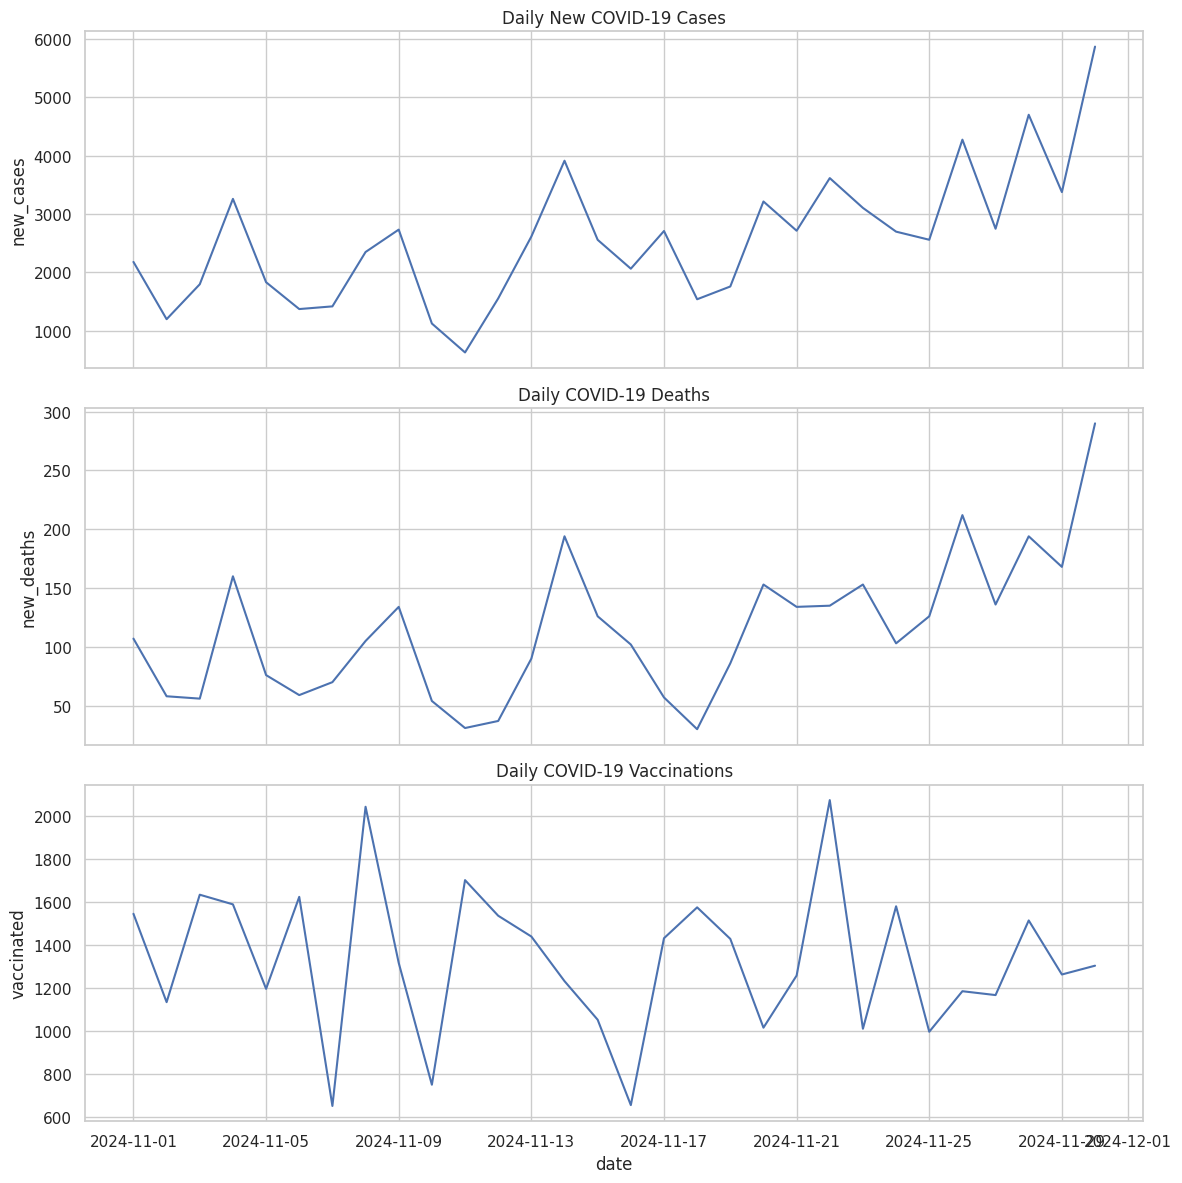

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# Group by date to get daily totals
daily_totals = df.groupby('date').agg({
    'new_cases': 'sum',
    'new_deaths': 'sum',
    'vaccinated': 'sum'
}).reset_index()

# Create cumulative columns
daily_totals['cumulative_cases'] = daily_totals['new_cases'].cumsum()
daily_totals['cumulative_deaths'] = daily_totals['new_deaths'].cumsum()
daily_totals['cumulative_vaccinated'] = daily_totals['vaccinated'].cumsum()

# Plotting daily trends
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Daily new cases
sns.lineplot(data=daily_totals, x='date', y='new_cases', ax=axs[0])
axs[0].set_title("Daily New COVID-19 Cases")

# Daily deaths
sns.lineplot(data=daily_totals, x='date', y='new_deaths', ax=axs[1])
axs[1].set_title("Daily COVID-19 Deaths")

# Daily vaccinations
sns.lineplot(data=daily_totals, x='date', y='vaccinated', ax=axs[2])
axs[2].set_title("Daily COVID-19 Vaccinations")

plt.tight_layout()
plt.show()

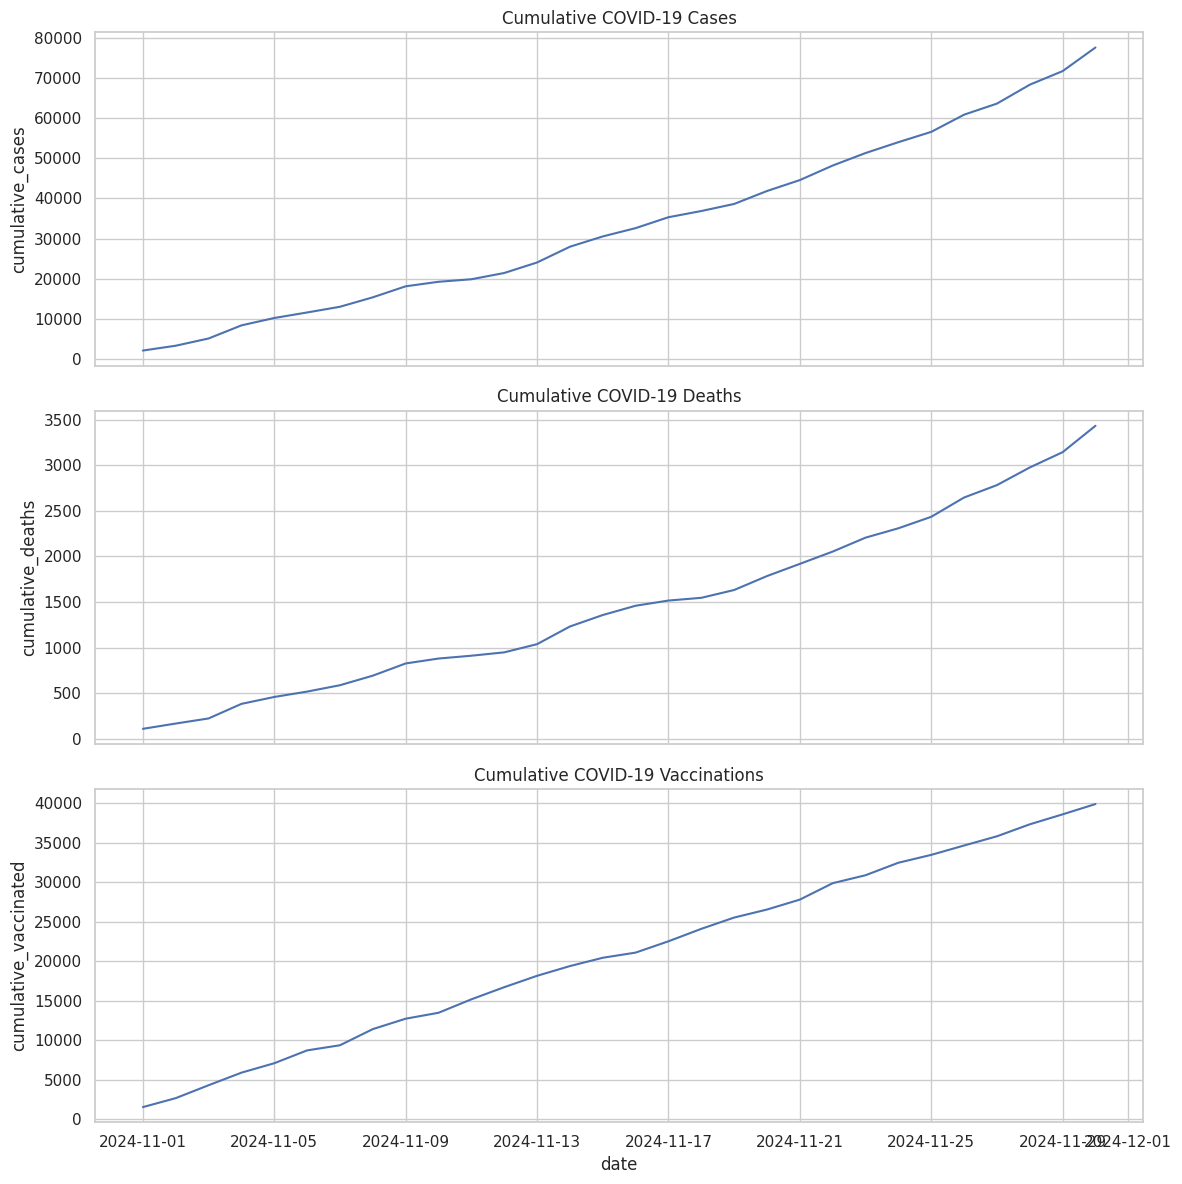

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by date
daily_totals = df.groupby('date').agg({
    'new_cases': 'sum',
    'new_deaths': 'sum',
    'vaccinated': 'sum'
}).reset_index()

# Create cumulative columns
daily_totals['cumulative_cases'] = daily_totals['new_cases'].cumsum()
daily_totals['cumulative_deaths'] = daily_totals['new_deaths'].cumsum()
daily_totals['cumulative_vaccinated'] = daily_totals['vaccinated'].cumsum()

# Plot
sns.set(style="whitegrid")
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

sns.lineplot(data=daily_totals, x='date', y='cumulative_cases', ax=axs[0])
axs[0].set_title("Cumulative COVID-19 Cases")

sns.lineplot(data=daily_totals, x='date', y='cumulative_deaths', ax=axs[1])
axs[1].set_title("Cumulative COVID-19 Deaths")

sns.lineplot(data=daily_totals, x='date', y='cumulative_vaccinated', ax=axs[2])
axs[2].set_title("Cumulative COVID-19 Vaccinations")

plt.tight_layout()
plt.show()

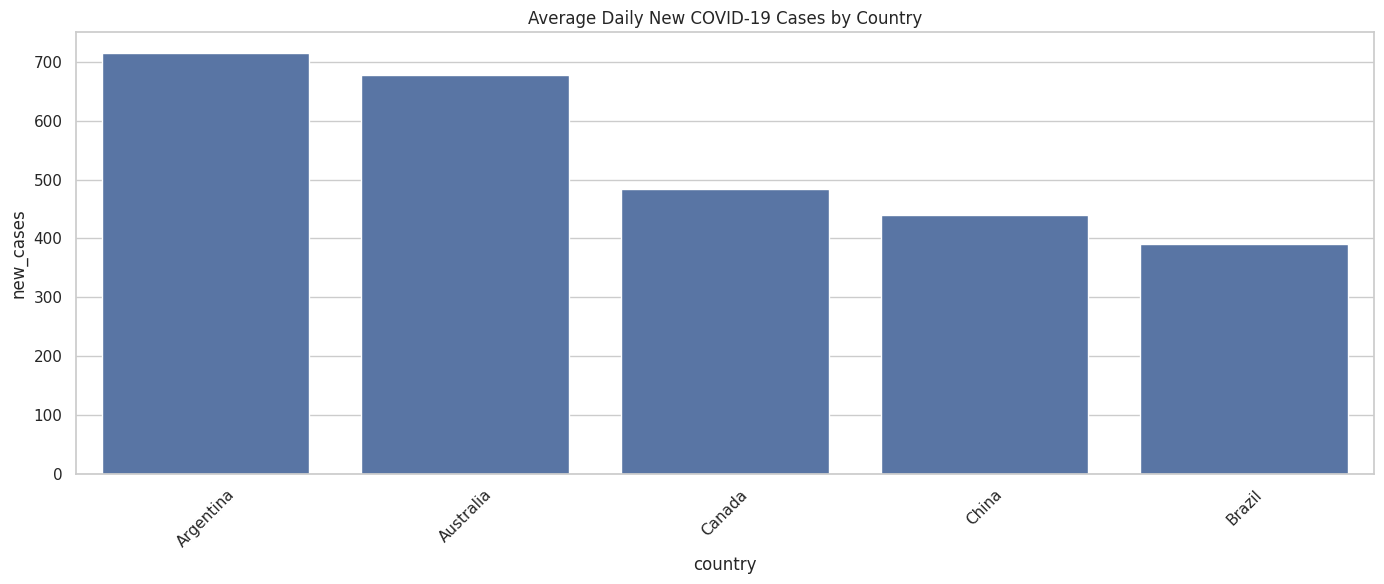

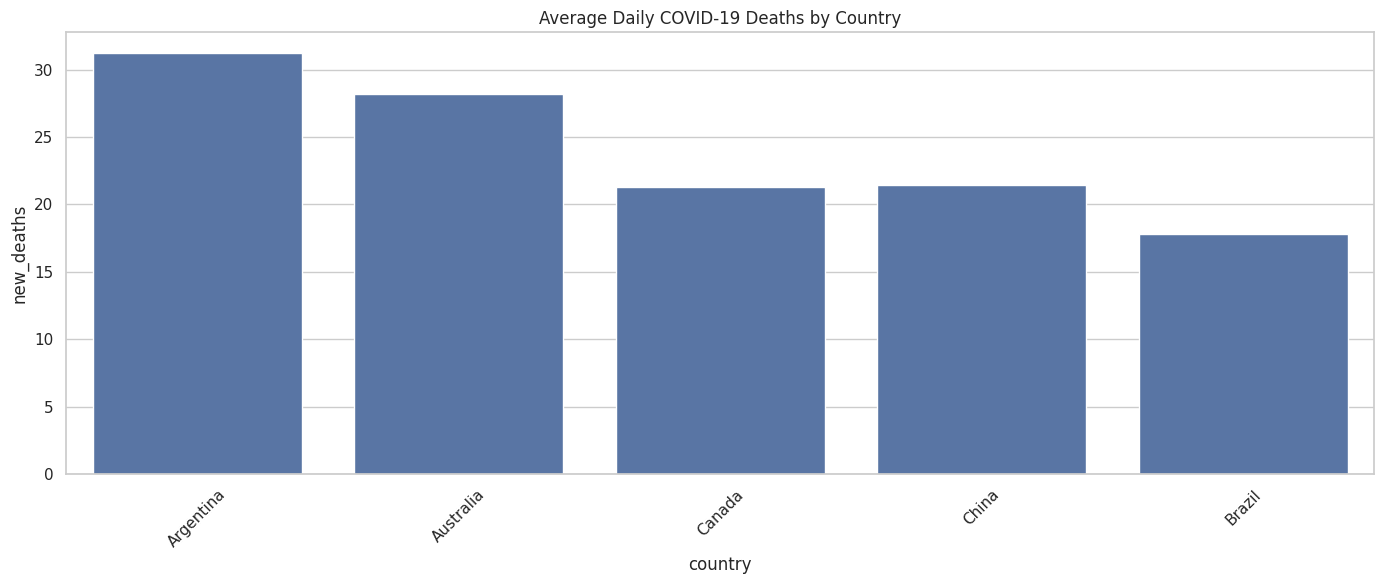

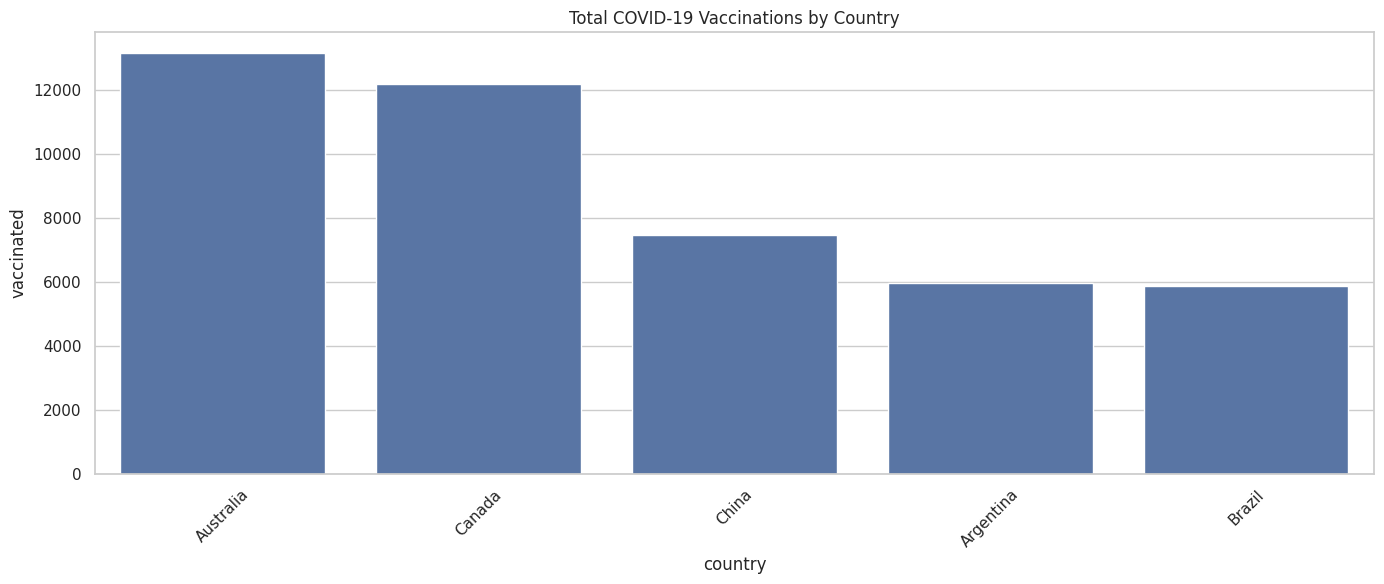

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by country for comparison
country_stats = df.groupby('country').agg({
    'new_cases': 'mean',
    'new_deaths': 'mean',
    'vaccinated': 'sum'
}).reset_index()

# Sort for better visualization
country_stats.sort_values(by='new_cases', ascending=False, inplace=True)

# Plotting
plt.figure(figsize=(14, 6))
sns.barplot(data=country_stats, x='country', y='new_cases')
plt.xticks(rotation=45)
plt.title("Average Daily New COVID-19 Cases by Country")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=country_stats, x='country', y='new_deaths')
plt.xticks(rotation=45)
plt.title("Average Daily COVID-19 Deaths by Country")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
country_stats_sorted_vax = country_stats.sort_values(by='vaccinated', ascending=False)
sns.barplot(data=country_stats_sorted_vax, x='country', y='vaccinated')
plt.xticks(rotation=45)
plt.title("Total COVID-19 Vaccinations by Country")
plt.tight_layout()
plt.show()

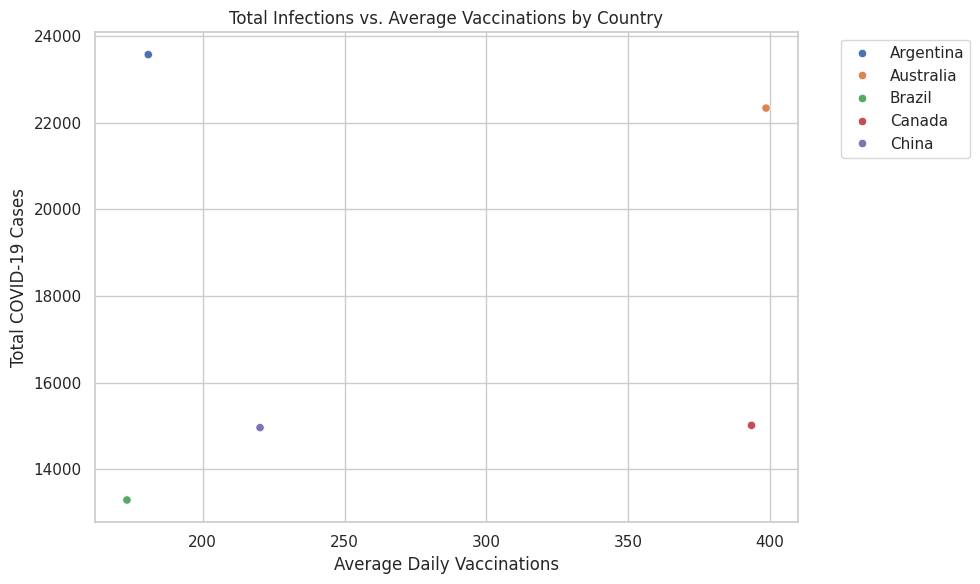

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate total infections and average vaccinations per country
scatter_data = df.groupby('country').agg({
    'new_cases': 'sum',
    'vaccinated': 'mean'
}).reset_index()

# Rename for clarity
scatter_data.rename(columns={'new_cases': 'total_cases', 'vaccinated': 'avg_vaccinated'}, inplace=True)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_data, x='avg_vaccinated', y='total_cases', hue='country')
plt.title("Total Infections vs. Average Vaccinations by Country")
plt.xlabel("Average Daily Vaccinations")
plt.ylabel("Total COVID-19 Cases")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()